In [1]:
from matchms.importing import load_from_mgf
dataset = list(load_from_mgf("/Users/rtlortega/Documents/PhD/Datasets/merged_and_cleaned_libraries_1.mgf"))
len(dataset)


1017531

FILTERING:
MS2 level = 1,017,531
Positive mode: 701,790
Corinna Brungs:  304,872

In [2]:
dataset[0].metadata

{'charge': 1,
 'description': 'ENAMMOL',
 'formula': 'C20H20FNO4',
 'inchi': 'InChI=1S/C20H20FNO4/c1-25-17-7-3-6-15-16-10-22(9-13-4-2-5-14(21)8-13)11-20(16,19(23)24)12-26-18(15)17/h2-8,16H,9-12H2,1H3,(H,23,24)/t16-,20-/m1/s1',
 'smiles': 'COc1cccc2c1OC[C@]1(C(=O)O)CN(Cc3cc(F)ccc3)C[C@H]21',
 'feature_id': '20240405_pluskal_enammol_5004_A22_id_MSn_positive.mzML msn trees:17',
 'adduct': '[M+Na]+',
 'feature_ms1_height': '4.404E7',
 'spectype': 'SAME_ENERGY',
 'collision_energy': '60.0',
 'fragmentation_method': 'HCD',
 'isolation_window': '1.2000000476839432',
 'acquisition': 'Commercial',
 'ims_type': 'none',
 'ion_source': 'ESI',
 'ionmode': 'positive',
 'dataset_id': 'MSV000094528',
 'usi': '[mzspec:MSV000094528:20240405_pluskal_enammol_5004_A22_id_MSn_positive:256, mzspec:MSV000094528:20240405_pluskal_enammol_5004_A22_id_MSn_positive:786]',
 'scans': '256,786',
 'precursor_purity': '1.0',
 'quality_chimeric': 'PASSED',
 'quality_explained_intensity': '0.96458876',
 'quality_explaine

In [3]:
from collections import Counter

ionisation = [spectrum.get("ms_mass_analyzer") for spectrum in dataset]
print(Counter(ionisation))

Counter({'orbitrap': 558457, 'Orbitrap': 304872, 'qtof': 85074, 'ftms': 56992, 'quadrupole': 6195, 'ion trap': 5461, None: 409, 'tof': 71})


In [4]:
spec_filtered=[]
for spec in dataset:
    if spec.get("ms_level")=="2" and spec.get("ionmode")=="positive" and spec.get("smiles") and spec.get("data_collector") == 'Corinna Brungs':
        spec_filtered.append(spec)

In [5]:
len(spec_filtered)

191308

InChIKeys are intended to be unique identifiers for chemical substances

In [6]:
seen_inchikeys = set()
unique_spectra = []
    
for spec in spec_filtered:
    inchikey = spec.get("inchikey")
    if inchikey and inchikey not in seen_inchikeys:
        seen_inchikeys.add(inchikey)
        unique_spectra.append(spec)

In [7]:
len(unique_spectra)

41568

In [10]:
from matchms.exporting import save_as_mgf

save_as_mgf(unique_spectra, "Corinna_Library_filtered_positive.mgf")


dict_keys(['spectra'])


In [ ]:
only_inchikeys = [spec.get("inchikey") for spec in spec_filtered_more_adducts]
print(len(only_inchikeys))

NameError: name 'spec_filtered_more_adducts' is not defined

In [ ]:
from collections import defaultdict


duplicates = defaultdict(list)

# iterate over positions and numbers simultaneously
for i, number in enumerate(only_inchikeys):
    # accumulate positions to the same number
    duplicates[number].append(i)

result = {key: value for key, value in duplicates.items()}


In [ ]:
result

{'NHWREWFNNXLTDT-UHFFFAOYSA-N': [0, 1],
 'ZWHHBRKAHNHHDN-UHFFFAOYSA-N': [2, 3],
 'DVUSXQGMZHRAPP-UHFFFAOYSA-N': [4, 5],
 'OHLKQPVOQXXCDW-UHFFFAOYSA-N': [6, 7],
 'DGUQEGBVTIEEKQ-UHFFFAOYSA-N': [8, 9],
 'BEYMWEGJHMFOTQ-UHFFFAOYSA-N': [10, 11],
 'GASOXLGVGBVWMG-UHFFFAOYSA-N': [12, 13],
 'RUBCFBMNVLVTNK-UHFFFAOYSA-N': [14, 15],
 'XVCFDYYHZJBEBW-UHFFFAOYSA-N': [16],
 'NGTJUDHSIVXGMU-UHFFFAOYSA-N': [17, 18],
 'IVFAZMHRJRGODH-UHFFFAOYSA-N': [19, 20],
 'IRZQDMYEJPNDEN-UHFFFAOYSA-N': [21],
 'QBYKMWUKHHLWDS-UHFFFAOYSA-N': [22],
 'CDULPPOISZOUTK-UHFFFAOYSA-N': [23],
 'NKHUCLYOABFQOJ-UHFFFAOYSA-N': [24, 25],
 'UEFKMJWKPVAVND-UHFFFAOYSA-N': [26, 27],
 'KKZFEWUJXRWGJS-UHFFFAOYSA-N': [28, 29],
 'TWIMAQLGJSZRPW-UHFFFAOYSA-N': [30, 31],
 'LJABIYWOOVOKRK-UHFFFAOYSA-N': [32, 33],
 'ZUYWDWYKNJLVOJ-UHFFFAOYSA-N': [34],
 'QCAFIHFRESDDIR-UHFFFAOYSA-N': [35],
 'AYKFTXZIWVTYQM-UHFFFAOYSA-N': [36, 37],
 'CQEIZYGGTNLXOM-UHFFFAOYSA-N': [38, 39],
 'CFGKWSDAMXTRHE-ONGXEEELSA-N': [40, 41],
 'LDTABXJEQXILGO-UHFFFAOYS

In [ ]:
index_list = []
for value in result.values():
    if len(value)>1:
        index_list.append(value)

In [ ]:
len(index_list)

21673

In [ ]:
from matchms.similarity import CosineGreedy
similarity_measure = CosineGreedy()
from matchms import calculate_scores
similarity_measure = CosineGreedy()

low_scores = []
for i in index_list:
    scores = calculate_scores(references=[spec_filtered_more_adducts[i[0]]], queries=[spec_filtered_more_adducts[i[1]]], similarity_function=similarity_measure)
    for (reference, query, score) in scores:
        if score[0]<=0.99:
            low_scores.append((i[0], i[1], score[0], score[1]))

In [ ]:
len(low_scores)

2034

In [ ]:
2034/63329

0.03211798702016454

[M+H]+ [M+H]+


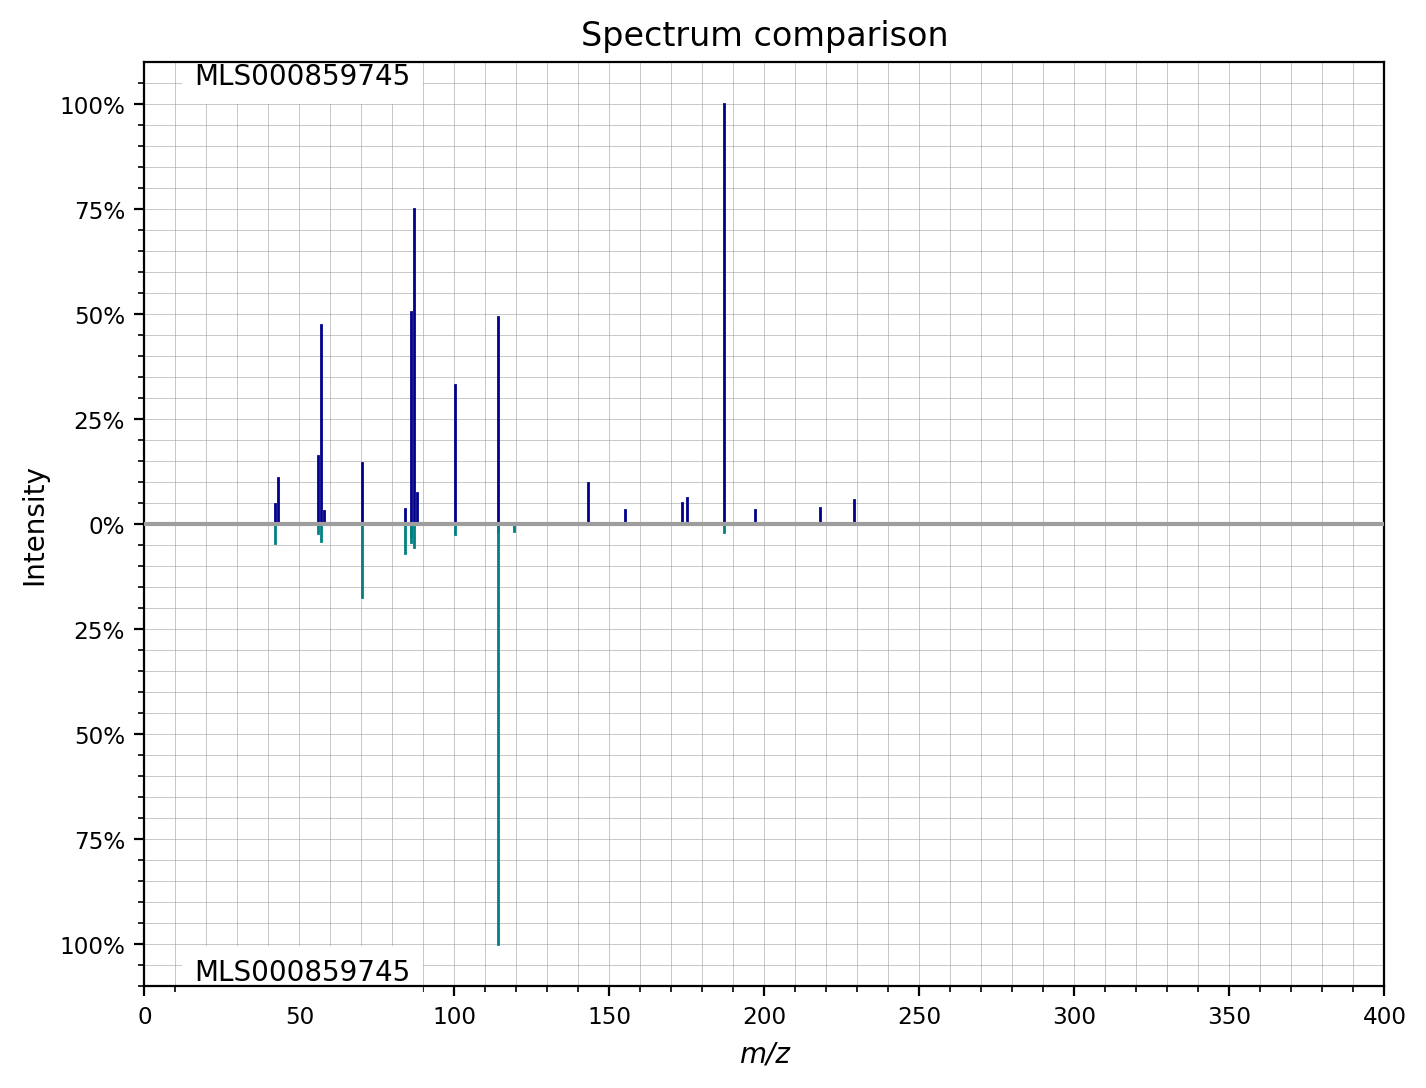

In [ ]:
spec_filtered_more_adducts[15569].plot_against(spec_filtered_more_adducts[15570])
print(spec_filtered_more_adducts[15569].get("adduct"), spec_filtered_more_adducts[15570].get("adduct"))

In [ ]:
spec_filtered_more[4601].metadata

{'charge': 1,
 'description': 'TMHTSNP',
 'formula': 'C27H30O15',
 'inchi': 'InChI=1S/C27H30O15/c1-9-17(31)20(34)22(36)26(39-9)38-8-15-18(32)21(35)23(37)27(41-15)42-25-19(33)16-13(30)6-12(29)7-14(16)40-24(25)10-2-4-11(28)5-3-10/h2-7,9,15,17-18,20-23,26-32,34-37H,8H2,1H3/t9-,15+,17-,18-,20+,21-,22+,23+,26+,27-/m0/s1',
 'smiles': 'C[C@@H]1O[C@@H](OC[C@H]2O[C@@H](Oc3c(-c4ccc(O)cc4)oc4cc(O)cc(O)c4c3=O)[C@H](O)[C@@H](O)[C@H]2O)[C@H](O)[C@H](O)[C@H]1O',
 'feature_id': '14',
 'featurelist_feature_id': '20241120_pluskal_targetmol_hts_np_5017_J18_id_MSn_positive.mzML msn trees:14',
 'adduct': '[M+H]+',
 'feature_ms1_height': '7.466E6',
 'spectype': 'SAME_ENERGY',
 'merged_across_n_samples': '1',
 'collision_energy': '60.0',
 'fragmentation_method': 'HCD',
 'isolation_window': '1.2000000476839432',
 'acquisition': 'Commercial',
 'ims_type': 'none',
 'ion_source': 'ESI',
 'ionmode': 'positive',
 'dataset_id': 'MSV000094528',
 'usi': 'mzspec:MSV000094528:20250228_targetmol_hts_np_pos_ms2:1370',
 '

In [ ]:
(89/68000)*100

0.13088235294117645